In [1]:
# Importing Required Libraries  
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sns

# Loading the Dataset 
df=pd.read_csv("Project_Resources/train.csv",index_col="Row_ID")

# Data Cleanup
df=df.convert_dtypes()
df["Postal_Code"]=df["Postal_Code"].fillna(0)
df["Postal_Code"]=df["Postal_Code"].astype(int)
l=["Order_Date","Ship_Date"]
for i in l:
    df[i]=pd.to_datetime(df[i],format="%d-%m-%Y")

# Sales Analysis
 
This Analysis will provide an insight on:
1. The performance of different categories of product over the year
2. The fluctuation of sales of a product category over some discreet month which may provide some valuable info.

In [8]:
df["Order_month_no"]=df["Order_Date"].dt.month
df_annual=df[df["Order_Date"].dt.year==2017]

`pivot_table()` This function helps us to acces the differnt attributes of the table and perform various aggrigation functions like mean, median, sum, count, etc. on it. 

In [30]:
df_pivot=df_annual.pivot_table(index="Order_month_no", values="Sales", columns="Category", aggfunc="sum", fill_value=0)
df_pivot

Category,Furniture,Office Supplies,Technology
Order_month_no,,,
1,7622.743,5299.682,5620.066
2,3925.551,6794.35,12258.914
3,12272.662,17324.545,21567.852
4,13212.09,10577.175,14890.502
5,14892.575,12931.642,28832.691
6,12450.524,10901.81,16372.152
7,12569.759,12903.824,12847.2
8,11910.0583,8959.74,9672.402
9,26755.4749,23013.402,19424.514


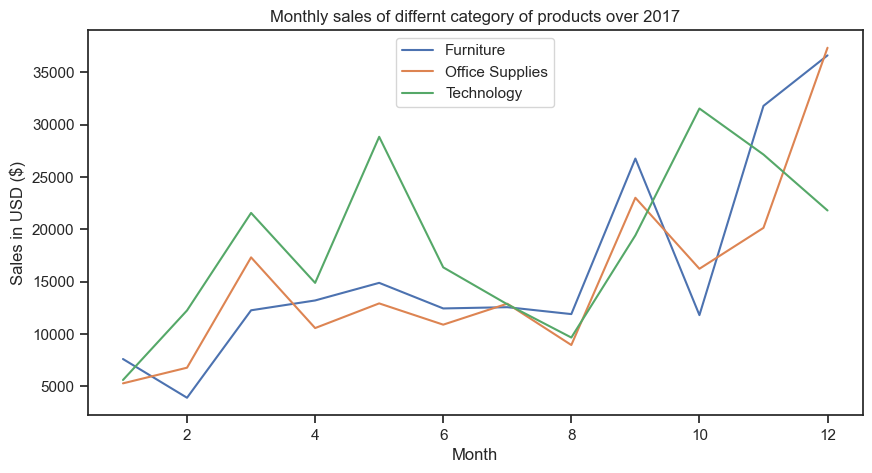

In [31]:
df_pivot.plot(kind="line", figsize=(10,5))
mp.title("Monthly sales of differnt category of products over 2017")
mp.xlabel("Month")
mp.ylabel("Sales in USD ($)")
mp.legend(loc="upper center")
mp.show()

The graph obtained above is sufficient for analysis but it requires some cleanup to draw our attention towards the important info. 

In [15]:
df_pivot=df_pivot.reset_index()
df_pivot["Order_month"]=df_pivot["Order_month_no"].apply(lambda x: pd.to_datetime(x, format="%m").strftime("%b"))
df_pivot=df_pivot.set_index("Order_month")
df_pivot=df_pivot.drop(columns="Order_month_no")

In [16]:
df_pivot

Category,Furniture,Office Supplies,Technology
Order_month,,,
Jan,7622.743,5299.682,5620.066
Feb,3925.551,6794.35,12258.914
Mar,12272.662,17324.545,21567.852
Apr,13212.09,10577.175,14890.502
May,14892.575,12931.642,28832.691
Jun,12450.524,10901.81,16372.152
Jul,12569.759,12903.824,12847.2
Aug,11910.0583,8959.74,9672.402
Sep,26755.4749,23013.402,19424.514


`text()` This fuctions adds the provided text to the graph according to the co-ordinates passed as arguments.  
`despine()` This functions removes the borders of the graph to provide a cleaner view.

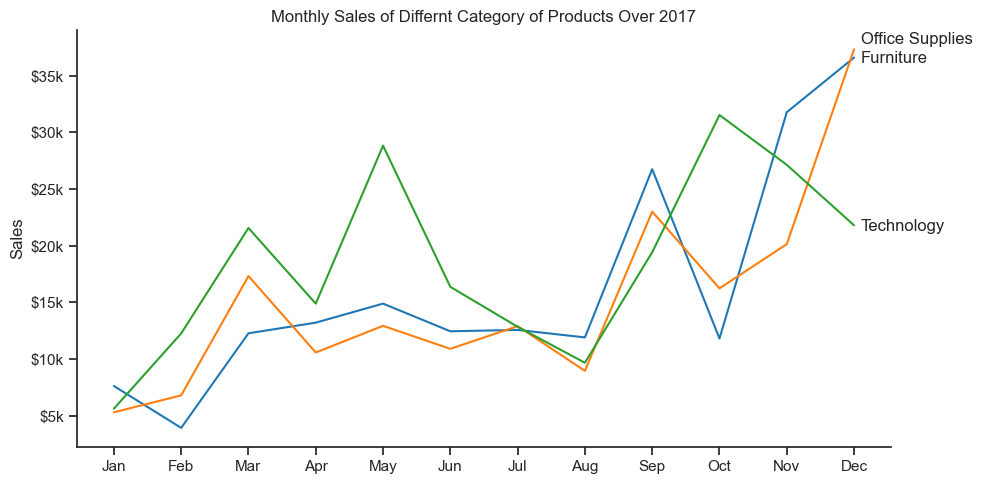

In [28]:
sns.lineplot(df_pivot, dashes=False, palette="tab10", legend=False)
sns.set_theme(style="ticks")
sns.despine()

mp.title("Monthly Sales of Differnt Category of Products Over 2017")
mp.xlabel("")
mp.ylabel("Sales")
for i in range(3):
    if i==1:
        mp.text(11.1, df_pivot.iloc[-1, i] + 500 , df_pivot.columns[i])  
    else:
        mp.text(11.1, df_pivot.iloc[-1, i] - 500 , df_pivot.columns[i])
ax=mp.gca()
fig=mp.gcf()
fig.set_size_inches(10,5)
ax.yaxis.set_major_formatter(mp.FuncFormatter(lambda y,pos: f"${int(y/1000)}k"))
mp.tight_layout()
mp.show()